In [ ]:
# ============================================================
# CORN PLANT DISEASE DETECTION
# PHASE 1: DATA COLLECTION
# CELLS 1–7 COMBINED INTO ONE CELL
# ============================================================

# ============================================================
# 1. INSTALL + IMPORT LIBRARIES
# ============================================================

!pip -q install kagglehub requests tqdm pillow pandas matplotlib seaborn

import os
import re
import csv
import json
import shutil
import hashlib
import random
import zipfile
import requests
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

import kagglehub

print("Libraries imported successfully.")

# ============================================================
# 2. PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = Path("/content/Plant Disease Detection (Computer Vision)")

RAW_ROOT = PROJECT_ROOT / "1st Raw_Data" / "Corn"
VERIFICATION_ROOT = PROJECT_ROOT / "2nd Data_Verification" / "Corn"

INTERNAL_ROOT = RAW_ROOT / "Internal_PlantVillage"
EXTERNAL_ROOT = RAW_ROOT / "External_Natural"

FINAL_ROOT = RAW_ROOT / "Final_Combined"

REPORT_ROOT = VERIFICATION_ROOT / "Reports"
SAMPLE_ROOT = VERIFICATION_ROOT / "Samples"

FINAL_CLASSES = [
    "Healthy",
    "Common_Rust",
    "Northern_Leaf_Blight"
]

# ------------------------------------------------------------
# LOCKED DATA COLLECTION STRATEGY
# ------------------------------------------------------------
# 300 final images per class
# = 150 Internal PlantVillage
# + 150 External Natural/Field
# ------------------------------------------------------------

TARGET_PER_CLASS = 600
INTERNAL_TARGET_PER_CLASS = 300
EXTERNAL_TARGET_PER_CLASS = 300

TOTAL_TARGET = TARGET_PER_CLASS * len(FINAL_CLASSES)

VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================
# 3. CREATE PROJECT FOLDERS
# ============================================================

for folder in [
    PROJECT_ROOT,
    RAW_ROOT,
    VERIFICATION_ROOT,
    INTERNAL_ROOT,
    EXTERNAL_ROOT,
    FINAL_ROOT,
    REPORT_ROOT,
    SAMPLE_ROOT
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Target: {TOTAL_TARGET} final images")
print(f"Target per class: {TARGET_PER_CLASS}")
print(f"Internal target per class: {INTERNAL_TARGET_PER_CLASS}")
print(f"External target per class: {EXTERNAL_TARGET_PER_CLASS}")
print(f"Classes: {FINAL_CLASSES}")

# ============================================================
# 4. DATASET SOURCE INFORMATION
# ============================================================

SOURCE_INFO = {
    "Internal": {
        "name": "PlantVillage",
        "purpose": "Controlled/lab baseline",
        "target_per_class": INTERNAL_TARGET_PER_CLASS,
        "expected_classes": FINAL_CLASSES
    },

    "External": {
        "name": "External Natural/Field Maize Dataset",
        "purpose": "Real-world / field generalization data",
        "target_per_class": EXTERNAL_TARGET_PER_CLASS,
        "expected_classes": FINAL_CLASSES
    }
}

print("\nDataset Source Information:")
print(json.dumps(SOURCE_INFO, indent=4))

# ============================================================
# 5. DOWNLOAD PLANTVILLAGE
# ============================================================

print("\n============================================================")
print("PLANTVILLAGE DATASET")
print("============================================================")

print("Downloading PlantVillage dataset...")
print("This may take some time depending on Colab connection.")

try:

    plantvillage_path = kagglehub.dataset_download(
        "abdallahalidev/plantvillage-dataset"
    )

    print("\nPlantVillage downloaded successfully.")
    print("Downloaded path:")
    print(plantvillage_path)

except Exception as e:

    print("\nERROR while downloading PlantVillage:")
    print(e)

    raise RuntimeError(
        "PlantVillage download failed. "
        "Please rerun this cell after checking the Colab connection."
    )

# ============================================================
# 6. FIND CORN CLASSES
# ============================================================
#
# IMPORTANT FIX:
#
# PlantVillage actual folder names are commonly:
#
# Corn_(maize)___healthy
# Corn_(maize)___Common_rust_
# Corn_(maize)___Northern_Leaf_Blight
#
# Therefore we DO NOT use exact folder-name matching.
# Instead, we verify:
#   1. Corn/Maize is present
#   2. Correct disease name is present
#
# ============================================================

def normalize_name(name):

    name = str(name).lower()

    name = name.replace("-", "_")
    name = name.replace(" ", "_")

    name = re.sub(
        r"[^a-z0-9_]",
        "",
        name
    )

    return name


def identify_corn_class(folder_name):

    """
    Identify only the three required Corn classes.

    The folder must first indicate CORN/MAIZE.
    This prevents unrelated plant disease folders
    from being incorrectly selected.
    """

    name = normalize_name(folder_name)

    # --------------------------------------------------------
    # Must be a Corn/Maize folder
    # --------------------------------------------------------

    if not (
        "corn" in name
        or "maize" in name
    ):
        return None

    # --------------------------------------------------------
    # Healthy
    # --------------------------------------------------------

    if "healthy" in name:

        return "Healthy"

    # --------------------------------------------------------
    # Common Rust
    # --------------------------------------------------------

    if (
        "common_rust" in name
        or "commonrust" in name
    ):

        return "Common_Rust"

    # --------------------------------------------------------
    # Northern Leaf Blight
    # --------------------------------------------------------

    if (
        "northern_leaf_blight" in name
        or "northernleafblight" in name
    ):

        return "Northern_Leaf_Blight"

    # --------------------------------------------------------
    # Anything else is ignored
    # --------------------------------------------------------

    return None


print("\nSearching PlantVillage for required Corn classes...\n")

internal_matches = {
    cls: []
    for cls in FINAL_CLASSES
}

for p in Path(plantvillage_path).rglob("*"):

    if not p.is_dir():
        continue

    detected_class = identify_corn_class(p.name)

    if detected_class is not None:

        internal_matches[
            detected_class
        ].append(p)


# ============================================================
# DISPLAY MATCHING FOLDERS
# ============================================================

for class_name in FINAL_CLASSES:

    print(f"{class_name}:")

    matches = internal_matches[class_name]

    if matches:

        for m in matches[:10]:
            print("   ", m)

    else:

        print("    NOT FOUND")

    print()


# ============================================================
# SAFETY CHECK
# ============================================================

missing_classes = [
    cls
    for cls in FINAL_CLASSES
    if len(internal_matches[cls]) == 0
]

if missing_classes:

    print("ERROR: Required Corn classes were not found.")
    print("Missing:", missing_classes)

    raise RuntimeError(
        "PlantVillage class matching failed. "
        "Check the downloaded dataset structure."
    )

print("All three required PlantVillage Corn classes found successfully.")

# ============================================================
# 7. COPY EXACT INTERNAL TARGET
# ============================================================

print("\n============================================================")
print("COPYING INTERNAL PLANTVILLAGE DATA")
print("============================================================")

def get_image_files(source_folder):

    source_folder = Path(source_folder)

    image_files = []

    for file in source_folder.rglob("*"):

        if not file.is_file():
            continue

        if file.suffix.lower() in VALID_EXTENSIONS:

            image_files.append(file)

    return image_files


def copy_selected_images(
    source_folder,
    destination_folder,
    source_label,
    target_count
):

    source_folder = Path(source_folder)
    destination_folder = Path(destination_folder)

    destination_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    image_files = get_image_files(
        source_folder
    )

    # Reproducible selection
    random.Random(
        RANDOM_SEED
    ).shuffle(image_files)

    selected_files = image_files[
        :target_count
    ]

    copied = 0

    for file in selected_files:

        new_name = (
            f"{source_label}_"
            f"{file.stem}_"
            f"{copied:06d}"
            f"{file.suffix.lower()}"
        )

        destination = (
            destination_folder /
            new_name
        )

        shutil.copy2(
            file,
            destination
        )

        copied += 1

    return len(image_files), copied


# ------------------------------------------------------------
# CLEAN PREVIOUS INTERNAL DATA
# ------------------------------------------------------------
#
# This makes the cell safe to rerun and prevents duplicate
# copies from previous executions.
# ------------------------------------------------------------

for class_name in FINAL_CLASSES:

    destination_folder = (
        INTERNAL_ROOT /
        class_name
    )

    if destination_folder.exists():

        shutil.rmtree(
            destination_folder
        )

    destination_folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# COPY 150 IMAGES PER CLASS
# ------------------------------------------------------------

internal_counts = {}

for class_name in FINAL_CLASSES:

    matches = internal_matches[
        class_name
    ]

    # Use the first matching valid PlantVillage folder
    source_folder = matches[0]

    destination_folder = (
        INTERNAL_ROOT /
        class_name
    )

    available, copied = copy_selected_images(
        source_folder=source_folder,
        destination_folder=destination_folder,
        source_label="PV",
        target_count=INTERNAL_TARGET_PER_CLASS
    )

    internal_counts[
        class_name
    ] = copied

    print(
        f"{class_name}: "
        f"{copied}/{INTERNAL_TARGET_PER_CLASS} copied "
        f"(available: {available})"
    )


# ============================================================
# INTERNAL DATASET CHECK
# ============================================================

print("\nInternal dataset summary:")

internal_total = 0

for cls in FINAL_CLASSES:

    count = len(
        [
            f for f in
            (INTERNAL_ROOT / cls).rglob("*")
            if f.is_file()
            and f.suffix.lower() in VALID_EXTENSIONS
        ]
    )

    internal_total += count

    print(
        f"{cls}: {count}"
    )

print(
    f"\nTotal Internal images: {internal_total}"
)

# ============================================================
# EXTERNAL DATASET INPUT LOCATION
# ============================================================

print("\n============================================================")
print("EXTERNAL DATASET")
print("============================================================")

print("""
External natural/field dataset is kept separate from
PlantVillage.

Required final folder structure:

External_Natural/
│
├── Healthy/
├── Common_Rust/
└── Northern_Leaf_Blight/

Each class should contain natural/real-world/field
maize leaf images.

IMPORTANT:
Do NOT rename an unknown disease into
Northern_Leaf_Blight.

The original external dataset must explicitly identify
the image/class as Northern Leaf Blight.
""")

print("\nExternal dataset location:")
print(EXTERNAL_ROOT)

print("\nExpected classes:")

for cls in FINAL_CLASSES:
    print(" -", cls)

# ============================================================
# FINAL COLLECTION STATUS
# ============================================================

print("\n============================================================")
print("PHASE 1 — COLLECTION STATUS")
print("============================================================")

print(f"Internal target: {INTERNAL_TARGET_PER_CLASS} per class")
print(f"External target: {EXTERNAL_TARGET_PER_CLASS} per class")
print(f"Final target: {TARGET_PER_CLASS} per class")
print(f"Total final target: {TOTAL_TARGET}")

print("\nInternal collected:")

for cls in FINAL_CLASSES:
    print(
        f"  {cls}: "
        f"{internal_counts.get(cls, 0)}"
    )

print("\nExternal dataset location prepared:")
print(EXTERNAL_ROOT)

print("\n============================================================")
print("DATA COLLECTION CELL COMPLETED")
print("============================================================")

Libraries imported successfully.
Project folders created.
Project root: /content/Plant Disease Detection (Computer Vision)
Target: 1800 final images
Target per class: 600
Internal target per class: 300
External target per class: 300
Classes: ['Healthy', 'Common_Rust', 'Northern_Leaf_Blight']

Dataset Source Information:
{
    "Internal": {
        "name": "PlantVillage",
        "purpose": "Controlled/lab baseline",
        "target_per_class": 300,
        "expected_classes": [
            "Healthy",
            "Common_Rust",
            "Northern_Leaf_Blight"
        ]
    },
    "External": {
        "name": "External Natural/Field Maize Dataset",
        "purpose": "Real-world / field generalization data",
        "target_per_class": 300,
        "expected_classes": [
            "Healthy",
            "Common_Rust",
            "Northern_Leaf_Blight"
        ]
    }
}

PLANTVILLAGE DATASET
This may take some time depending on Colab connection.
Using Colab cache for faster access t

In [22]:
# ============================================================
# CELL 2: CORN EXTERNAL DATASET COLLECTION
# Source: GitHub — gitergo/Datasets
# Natural Environment Maize Disease Dataset
# ============================================================

import os
import re
import shutil
import random
import subprocess
from pathlib import Path

# ============================================================
# STEP 1: CONFIGURATION
# ============================================================

REPO_URL = "https://github.com/gitergo/Datasets.git"

DOWNLOAD_ROOT = RAW_ROOT / "Corn_Natural_GitHub"
REPO_ROOT = DOWNLOAD_ROOT / "Datasets"
NATURAL_ROOT = REPO_ROOT / "Natural_environment"

EXTERNAL_TARGET = 300
SEED = 42

REQUIRED_CLASSES = {
    "Healthy": ["healthy"],
    "Common_Rust": ["common_rust", "common rust"],
    "Northern_Leaf_Blight": [
        "northern_leaf_blight",
        "northern leaf blight"
    ]
}

DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
EXTERNAL_ROOT.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("CORN EXTERNAL DATASET COLLECTION")
print("=" * 70)

print("\nSource:")
print("gitergo/Datasets — Natural_environment")

print("\nRequired classes:")
for cls in FINAL_CLASSES:
    print(" -", cls)

print("\nTarget:")
print("300 images per class = 900 total")

# ============================================================
# STEP 2: DOWNLOAD GITHUB DATASET
# ============================================================

print("\n" + "=" * 70)
print("DOWNLOADING NATURAL ENVIRONMENT DATASET")
print("=" * 70)

if REPO_ROOT.exists():
    print("Existing repository found. Removing old copy...")
    shutil.rmtree(REPO_ROOT)

print("\nCloning repository...")

result = subprocess.run(
    [
        "git",
        "clone",
        "--depth", "1",
        REPO_URL,
        str(REPO_ROOT)
    ],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)

    raise RuntimeError(
        "GitHub dataset download failed."
    )

print("GitHub repository downloaded successfully.")

if not NATURAL_ROOT.exists():
    raise RuntimeError(
        f"Natural_environment folder not found:\n"
        f"{NATURAL_ROOT}"
    )

print("\nNatural environment dataset found:")
print(NATURAL_ROOT)

# ============================================================
# STEP 3: INSPECT FOLDER STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("DATASET FOLDER STRUCTURE")
print("=" * 70)

for root_dir, dirs, files in os.walk(NATURAL_ROOT):

    img_count = sum(
        1
        for f in files
        if Path(f).suffix.lower() in VALID_EXTENSIONS
    )

    level = (
        root_dir.replace(str(NATURAL_ROOT), "")
        .count(os.sep)
    )

    indent = "  " * level
    folder_name = os.path.basename(root_dir)

    print(
        f"{indent}{folder_name}/ "
        f"[{img_count} images]"
    )

# ============================================================
# STEP 4: CLASS DETECTION
# ============================================================

def identify_external_corn_class(folder_name):

    name = folder_name.lower()

    name = name.replace("-", "_")
    name = name.replace(" ", "_")

    name = re.sub(
        r"[^a-z0-9_]",
        "",
        name
    )

    if (
        "northern_leaf_blight" in name
        or name == "northern_leaf_blight"
    ):
        return "Northern_Leaf_Blight"

    if (
        "common_rust" in name
        or name == "common_rust"
    ):
        return "Common_Rust"

    if (
        name == "healthy"
        or "healthy" in name
    ):
        return "Healthy"

    return None


print("\n" + "=" * 70)
print("CLASS DETECTION")
print("=" * 70)

class_matches = {
    cls: []
    for cls in FINAL_CLASSES
}

for root_dir, dirs, files in os.walk(NATURAL_ROOT):

    image_count = sum(
        1
        for f in files
        if Path(f).suffix.lower()
        in VALID_EXTENSIONS
    )

    if image_count == 0:
        continue

    folder_name = os.path.basename(root_dir)

    detected = identify_external_corn_class(
        folder_name
    )

    if detected:

        class_matches[
            detected
        ].append(Path(root_dir))

        print(
            f"✅ {folder_name}/ "
            f"→ {detected} "
            f"({image_count} images)"
        )

    else:

        print(
            f"⏭️ {folder_name}/ "
            f"→ skipped "
            f"({image_count} images)"
        )

# ============================================================
# STEP 5: VERIFY REQUIRED CLASSES
# ============================================================

print("\n" + "=" * 70)
print("VERIFYING REQUIRED CLASSES")
print("=" * 70)

missing = [
    cls
    for cls in FINAL_CLASSES
    if len(class_matches[cls]) == 0
]

if missing:

    print("\n❌ REQUIRED CLASS NOT FOUND")
    print("Missing:", missing)

    raise RuntimeError(
        "Required external classes were not found."
    )

print("\n✅ All 3 required classes found.")

for cls in FINAL_CLASSES:

    print(
        f"{cls}: "
        f"{len(class_matches[cls])} "
        f"matching folder(s)"
    )

# ============================================================
# STEP 6: GET ALL IMAGES
# ============================================================

def get_images(folder):

    return [
        f
        for f in Path(folder).rglob("*")
        if (
            f.is_file()
            and f.suffix.lower()
            in VALID_EXTENSIONS
        )
    ]


print("\n" + "=" * 70)
print("AVAILABLE IMAGES PER CLASS")
print("=" * 70)

available_images = {}

for cls in FINAL_CLASSES:

    images = []

    for folder in class_matches[cls]:

        images.extend(
            get_images(folder)
        )

    # Remove duplicate file paths
    images = list(
        dict.fromkeys(images)
    )

    available_images[cls] = images

    print(
        f"{cls}: "
        f"{len(images)} images available"
    )

# ============================================================
# STEP 7: CHECK 300 IMAGES AVAILABLE
# ============================================================

insufficient = [
    cls
    for cls in FINAL_CLASSES
    if len(available_images[cls])
    < EXTERNAL_TARGET
]

if insufficient:

    print("\n❌ INSUFFICIENT DATA")

    for cls in insufficient:

        print(
            f"{cls}: "
            f"{len(available_images[cls])} "
            f"< {EXTERNAL_TARGET}"
        )

    raise RuntimeError(
        "At least one required class has "
        "fewer than 300 images."
    )

print(
    "\n✅ At least 300 images available "
    "for every required class."
)

# ============================================================
# STEP 8: CLEAN OLD EXTERNAL DATA
# ============================================================

print("\n" + "=" * 70)
print("PREPARING External_Natural")
print("=" * 70)

for cls in FINAL_CLASSES:

    destination = EXTERNAL_ROOT / cls

    if destination.exists():

        shutil.rmtree(
            destination
        )

    destination.mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# STEP 9: SELECT AND COPY 300 IMAGES / CLASS
# ============================================================

print("\nCopying exactly 300 images per class...\n")

external_collected = {}

for cls in FINAL_CLASSES:

    images = list(
        available_images[cls]
    )

    rng = random.Random(
        SEED
    )

    rng.shuffle(images)

    selected = images[
        :EXTERNAL_TARGET
    ]

    destination_folder = (
        EXTERNAL_ROOT / cls
    )

    for idx, source_file in enumerate(
        selected,
        start=1
    ):

        destination_file = (
            destination_folder
            / f"Corn_{cls}_Ext_{idx:04d}"
              f"{source_file.suffix.lower()}"
        )

        shutil.copy2(
            source_file,
            destination_file
        )

    external_collected[cls] = len(
        selected
    )

    print(
        f"✅ {cls}: "
        f"{len(selected)} images copied"
    )

# ============================================================
# STEP 10: FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("EXTERNAL DATASET COLLECTION RESULT")
print("=" * 70)

total_external = 0
all_ok = True

for cls in FINAL_CLASSES:

    folder = (
        EXTERNAL_ROOT / cls
    )

    count = sum(
        1
        for f in folder.iterdir()
        if (
            f.is_file()
            and f.suffix.lower()
            in VALID_EXTENSIONS
        )
    )

    total_external += count

    if count != EXTERNAL_TARGET:
        all_ok = False

    print(
        f"{cls}: "
        f"{count} "
        f"{'✅' if count == EXTERNAL_TARGET else '❌'}"
    )

print(
    f"\nTotal External images: "
    f"{total_external}"
)

print(
    f"Location: "
    f"{EXTERNAL_ROOT}"
)

# ============================================================
# FINAL VALIDATION
# ============================================================

if (
    all_ok
    and total_external == 900
):

    print("\n" + "=" * 70)
    print("✅ PASS — EXTERNAL DATASET READY")
    print("=" * 70)

    print(
        "\n900 external images successfully collected."
    )

    print(
        "300 Healthy"
    )

    print(
        "300 Common Rust"
    )

    print(
        "300 Northern Leaf Blight"
    )

    print(
        "\n➡️ Now run Cell 3 (Verification)."
    )

else:

    raise RuntimeError(
        "External dataset collection did not "
        "produce exactly 900 images."
    )

print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

CORN EXTERNAL DATASET COLLECTION

Source:
gitergo/Datasets — Natural_environment

Required classes:
 - Healthy
 - Common_Rust
 - Northern_Leaf_Blight

Target:
300 images per class = 900 total

DOWNLOADING NATURAL ENVIRONMENT DATASET

Cloning repository...
GitHub repository downloaded successfully.

Natural environment dataset found:
/content/Plant Disease Detection (Computer Vision)/1st Raw_Data/Corn/Corn_Natural_GitHub/Datasets/Natural_environment

DATASET FOLDER STRUCTURE
Natural_environment/ [0 images]
  train/ [0 images]
    healthy/ [785 images]
    Cercospora_leaf_spot Gray_leaf_spot/ [171 images]
    Common_rust/ [1052 images]
    Northern_Leaf_Blight/ [358 images]
  test/ [0 images]
    healthy/ [112 images]
    Cercospora_leaf_spot Gray_leaf_spot/ [25 images]
    Common_rust/ [150 images]
    Northern_Leaf_Blight/ [51 images]
  val/ [0 images]
    healthy/ [225 images]
    Cercospora_leaf_spot Gray_leaf_spot/ [49 images]
    Common_rust/ [300 images]
    Northern_Leaf_Blight/ 

External dataset counts:

Healthy: 295
Common_Rust: 300
Northern_Leaf_Blight: 300

External dataset audit completed.
CLASS AVAILABILITY CHECK

Internal classes:
Healthy: PASS
Common_Rust: PASS
Northern_Leaf_Blight: PASS

External classes:
Healthy: PASS
Common_Rust: PASS
Northern_Leaf_Blight: PASS

PASS: Both datasets contain all 3 required classes.

Auditing Internal_PlantVillage: 900 images


  0%|          | 0/900 [00:00<?, ?it/s]


Auditing External_Natural: 895 images


  0%|          | 0/895 [00:00<?, ?it/s]


Audit saved:
/content/Plant Disease Detection (Computer Vision)/2nd Data_Verification/Corn/Reports/Corn_Image_Validation_Audit.csv
IMAGE VALIDATION SUMMARY


...

  0%|          | 0/1795 [00:00<?, ?it/s]


Final duplicate groups: 0
PASS: No exact duplicates in final dataset.

Auditing Corn_Final_Combined: 1795 images


  0%|          | 0/1795 [00:00<?, ?it/s]

,class,total,valid
0,Common_Rust,600,600
1,Healthy,595,595
2,Northern_Leaf_Blight,600,600



Final audit saved:
/content/Plant Disease Detection (Computer Vision)/2nd Data_Verification/Corn/Reports/Corn_Final_Dataset_Audit.csv


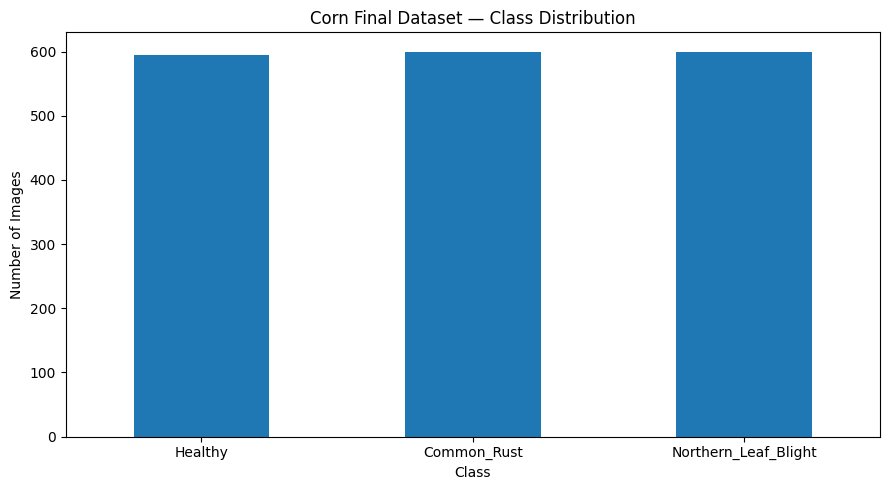

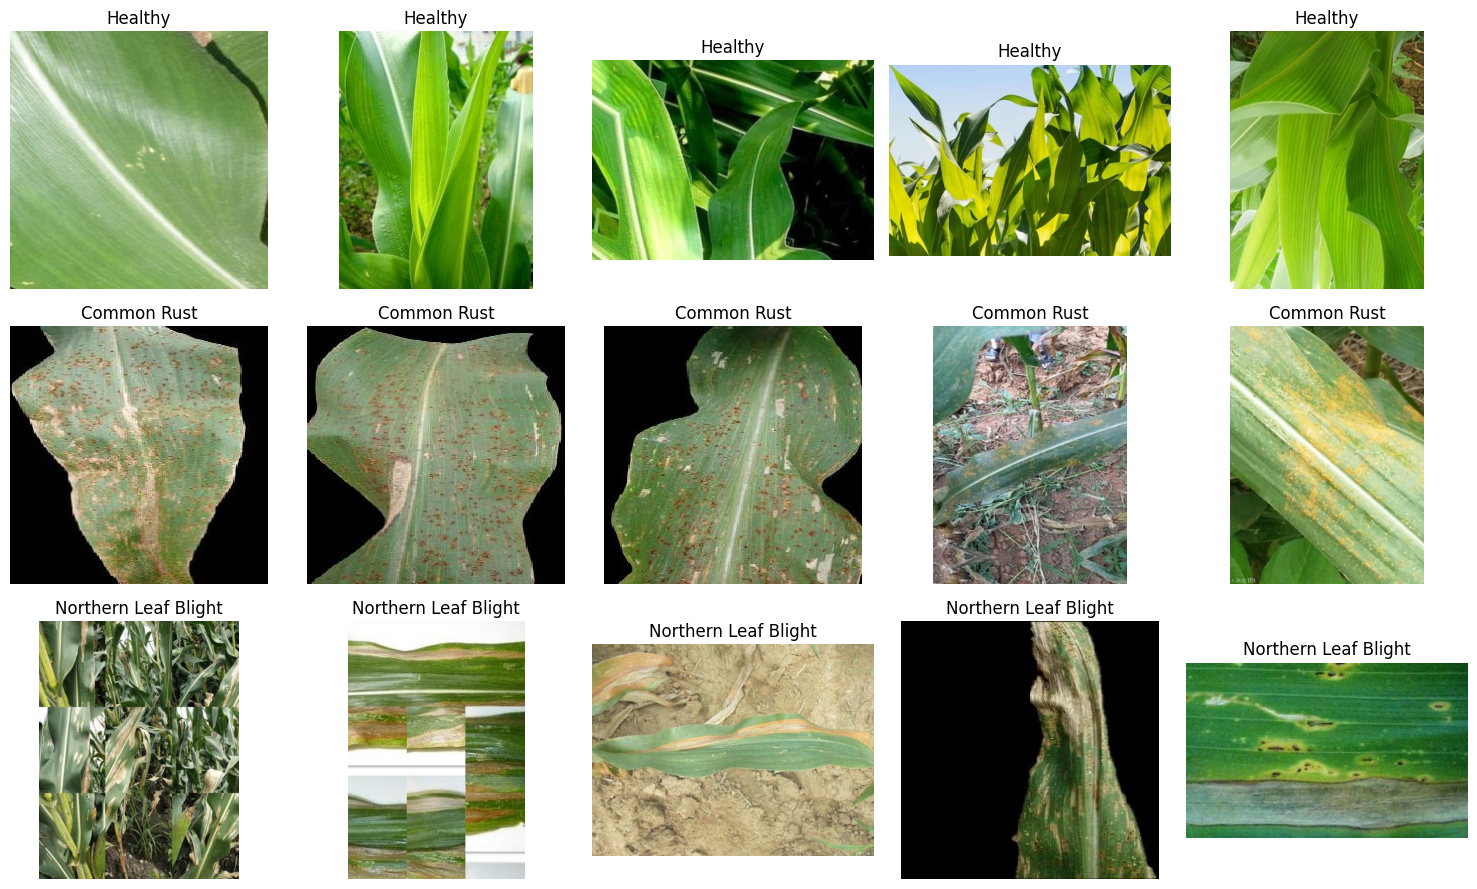

CORN — PHASE 1 FINAL AUDIT
PASS  |  3 required classes
PASS  |  Expected images per class
PASS  |  1795 total images
PASS  |  300 Internal + available External per class
PASS  |  All final images valid
PASS  |  No exact duplicates
PASS  |  Valid file extensions

🎉 PHASE 1 STATUS: PASS
Corn dataset collection + verification completed.
Final dataset: 1795 images
Source balance:
Healthy = 300 Internal + 295 External
Common Rust = 300 Internal + 300 External
Northern Leaf Blight = 300 Internal + 300 External
Next phase: Preprocessing → Model Pipeline
Master dataset CSV saved:
/content/Plant Disease Detection (Computer Vision)/2nd Data_Verification/Corn/Reports/Corn_Final_Master_Dataset.csv


In [26]:
# =============================================================================================
# Data Verification:
# =============================================================================================


# ============================================================
# EXTERNAL DATASET AUDIT
# ============================================================

def count_images(folder):
    folder = Path(folder)

    if not folder.exists():
        return 0

    return sum(
        1
        for f in folder.rglob("*")
        if f.is_file()
        and f.suffix.lower() in VALID_EXTENSIONS
    )


external_counts = {}

print("External dataset counts:\n")

for cls in FINAL_CLASSES:

    folder = EXTERNAL_ROOT / cls

    count = count_images(folder)

    external_counts[cls] = count

    print(f"{cls}: {count}")

print("\nExternal dataset audit completed.")

# ============================================================
# CLASS AVAILABILITY CHECK
# ============================================================

print("============================================================")
print("CLASS AVAILABILITY CHECK")
print("============================================================")

internal_ok = all(
    internal_counts.get(cls, 0) > 0
    for cls in FINAL_CLASSES
)

external_ok = all(
    external_counts.get(cls, 0) > 0
    for cls in FINAL_CLASSES
)

print("\nInternal classes:")
for cls in FINAL_CLASSES:
    status = "PASS" if internal_counts.get(cls, 0) > 0 else "FAIL"
    print(f"{cls}: {status}")

print("\nExternal classes:")
for cls in FINAL_CLASSES:
    status = "PASS" if external_counts.get(cls, 0) > 0 else "FAIL"
    print(f"{cls}: {status}")

if internal_ok and external_ok:
    print("\nPASS: Both datasets contain all 3 required classes.")
else:
    print("\nSTOP: Required external/internal class is missing.")
    print("Do NOT continue to final combination until the")
    print("source/class mapping is corrected.")

# ============================================================
# IMAGE VALIDATION
# ============================================================

def validate_image(file_path):

    result = {
        "valid": False,
        "width": None,
        "height": None,
        "mode": None,
        "format": None,
        "error": ""
    }

    try:

        with Image.open(file_path) as img:

            img.verify()

        with Image.open(file_path) as img:

            result["width"] = img.width
            result["height"] = img.height
            result["mode"] = img.mode
            result["format"] = img.format

        result["valid"] = True

    except Exception as e:

        result["error"] = str(e)

    return result


def audit_dataset(root, dataset_name):

    root = Path(root)

    rows = []

    files = [
        f
        for f in root.rglob("*")
        if f.is_file()
        and f.suffix.lower() in VALID_EXTENSIONS
    ]

    print(f"\nAuditing {dataset_name}: {len(files)} images")

    for file in tqdm(files):

        relative_parts = file.relative_to(root).parts

        class_name = (
            relative_parts[0]
            if len(relative_parts) > 1
            else "UNKNOWN"
        )

        result = validate_image(file)

        rows.append({
            "dataset": dataset_name,
            "class": class_name,
            "filename": file.name,
            "path": str(file),
            "extension": file.suffix.lower(),
            "valid": result["valid"],
            "width": result["width"],
            "height": result["height"],
            "mode": result["mode"],
            "format": result["format"],
            "error": result["error"]
        })

    return pd.DataFrame(rows)


internal_audit = audit_dataset(
    INTERNAL_ROOT,
    "Internal_PlantVillage"
)

external_audit = audit_dataset(
    EXTERNAL_ROOT,
    "External_Natural"
)

full_audit = pd.concat(
    [internal_audit, external_audit],
    ignore_index=True
)

audit_path = REPORT_ROOT / "Corn_Image_Validation_Audit.csv"

full_audit.to_csv(
    audit_path,
    index=False
)

print("\nAudit saved:")
print(audit_path)

# ============================================================
# VALIDATION SUMMARY
# ============================================================

print("============================================================")
print("IMAGE VALIDATION SUMMARY")
print("============================================================")

summary = (
    full_audit
    .groupby(["dataset", "class"])
    .agg(
        total_images=("filename", "count"),
        valid_images=("valid", "sum")
    )
    .reset_index()
)

summary["invalid_images"] = (
    summary["total_images"]
    - summary["valid_images"]
)

display(summary)

print("\nTotal images:", len(full_audit))
print(
    "Valid images:",
    int(full_audit["valid"].sum())
)
print(
    "Invalid images:",
    int((~full_audit["valid"]).sum())
)

# ============================================================
# REMOVE INVALID / CORRUPT IMAGES
# ============================================================

invalid_files = full_audit[
    full_audit["valid"] == False
]

invalid_folder = VERIFICATION_ROOT / "Invalid_Images"

invalid_folder.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Invalid images found: {len(invalid_files)}"
)

for _, row in invalid_files.iterrows():

    source = Path(row["path"])

    if source.exists():

        destination = (
            invalid_folder /
            f"{row['dataset']}_{source.name}"
        )

        shutil.move(
            str(source),
            str(destination)
        )

print("Invalid-image handling completed.")

# ============================================================
# MD5 EXACT DUPLICATE DETECTION
# ============================================================

def md5_hash(file_path, chunk_size=1024 * 1024):

    md5 = hashlib.md5()

    with open(file_path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            md5.update(chunk)

    return md5.hexdigest()


def find_duplicates(root):

    root = Path(root)

    hash_map = defaultdict(list)

    files = [
        f
        for f in root.rglob("*")
        if f.is_file()
        and f.suffix.lower() in VALID_EXTENSIONS
    ]

    print(f"Checking {len(files)} images...")

    for file in tqdm(files):

        try:
            file_hash = md5_hash(file)
            hash_map[file_hash].append(file)

        except Exception:
            pass

    duplicates = {
        h: paths
        for h, paths in hash_map.items()
        if len(paths) > 1
    }

    return duplicates


internal_duplicates = find_duplicates(INTERNAL_ROOT)
external_duplicates = find_duplicates(EXTERNAL_ROOT)

print("\nInternal duplicate groups:",
      len(internal_duplicates))

print("External duplicate groups:",
      len(external_duplicates))

# ============================================================
# REMOVE EXACT DUPLICATE COPIES
# ============================================================

DUPLICATE_ROOT = VERIFICATION_ROOT / "Duplicate_Images"

DUPLICATE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


def remove_duplicate_copies(
    duplicate_groups,
    dataset_name
):

    removed = []

    dataset_duplicate_folder = (
        DUPLICATE_ROOT / dataset_name
    )

    dataset_duplicate_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    for file_hash, paths in duplicate_groups.items():

        # Keep first image
        keep = paths[0]

        # Move all additional copies
        for duplicate in paths[1:]:

            if duplicate.exists():

                destination = (
                    dataset_duplicate_folder /
                    duplicate.name
                )

                # Avoid filename collision
                counter = 1

                while destination.exists():

                    destination = (
                        dataset_duplicate_folder /
                        f"{duplicate.stem}_duplicate_{counter}"
                        f"{duplicate.suffix}"
                    )

                    counter += 1

                shutil.move(
                    str(duplicate),
                    str(destination)
                )

                removed.append({
                    "hash": file_hash,
                    "kept": str(keep),
                    "removed": str(destination)
                })

    return removed


internal_removed = remove_duplicate_copies(
    internal_duplicates,
    "Internal_PlantVillage"
)

external_removed = remove_duplicate_copies(
    external_duplicates,
    "External_Natural"
)

duplicate_log = pd.DataFrame(
    internal_removed + external_removed
)

duplicate_log_path = (
    REPORT_ROOT /
    "Corn_Duplicate_Removal_Log.csv"
)

duplicate_log.to_csv(
    duplicate_log_path,
    index=False
)

print(
    "Duplicate copies removed:",
    len(duplicate_log)
)

# ============================================================
# FIX 2:
# CROSS-SOURCE EXACT DUPLICATE DETECTION
# ============================================================

def find_cross_source_duplicates(
    internal_root,
    external_root
):

    hash_map = defaultdict(list)

    roots = [
        ("Internal_PlantVillage", Path(internal_root)),
        ("External_Natural", Path(external_root))
    ]

    for dataset_name, root in roots:

        files = [
            f
            for f in root.rglob("*")
            if f.is_file()
            and f.suffix.lower() in VALID_EXTENSIONS
        ]

        print(
            f"Checking {dataset_name}: "
            f"{len(files)} images..."
        )

        for file in tqdm(files):

            try:

                file_hash = md5_hash(file)

                hash_map[file_hash].append(
                    (dataset_name, file)
                )

            except Exception:
                pass

    cross_source_duplicates = {}

    for file_hash, entries in hash_map.items():

        source_names = {
            entry[0]
            for entry in entries
        }

        # Only keep duplicates that exist
        # across different sources.
        if (
            "Internal_PlantVillage" in source_names
            and
            "External_Natural" in source_names
        ):

            cross_source_duplicates[
                file_hash
            ] = entries

    return cross_source_duplicates


cross_source_duplicates = find_cross_source_duplicates(
    INTERNAL_ROOT,
    EXTERNAL_ROOT
)

print(
    "\nCross-source duplicate groups:",
    len(cross_source_duplicates)
)

# ============================================================
# REMOVE CROSS-SOURCE DUPLICATES
# ============================================================

cross_source_removed = []

cross_duplicate_folder = (
    DUPLICATE_ROOT /
    "Cross_Source"
)

cross_duplicate_folder.mkdir(
    parents=True,
    exist_ok=True
)

for file_hash, entries in cross_source_duplicates.items():

    # Keep Internal PlantVillage copy when
    # the same exact image exists in both sources.
    internal_entries = [
        file
        for source, file in entries
        if source == "Internal_PlantVillage"
    ]

    external_entries = [
        file
        for source, file in entries
        if source == "External_Natural"
    ]

    if internal_entries:

        keep = internal_entries[0]

        files_to_remove = external_entries

    else:

        keep = entries[0][1]

        files_to_remove = [
            file
            for _, file in entries[1:]
        ]

    for duplicate in files_to_remove:

        if duplicate.exists():

            destination = (
                cross_duplicate_folder /
                duplicate.name
            )

            counter = 1

            while destination.exists():

                destination = (
                    cross_duplicate_folder /
                    f"{duplicate.stem}_duplicate_{counter}"
                    f"{duplicate.suffix}"
                )

                counter += 1

            shutil.move(
                str(duplicate),
                str(destination)
            )

            cross_source_removed.append({
                "hash": file_hash,
                "kept": str(keep),
                "removed": str(destination),
                "duplicate_source": "Cross_Source"
            })

cross_source_log = pd.DataFrame(
    cross_source_removed
)

cross_source_log_path = (
    REPORT_ROOT /
    "Corn_Cross_Source_Duplicate_Removal_Log.csv"
)

cross_source_log.to_csv(
    cross_source_log_path,
    index=False
)

print(
    "Cross-source duplicate copies removed:",
    len(cross_source_log)
)

# ============================================================
# RECOUNT AFTER CLEANING
# ============================================================

def class_counts(root):

    root = Path(root)

    result = {}

    for cls in FINAL_CLASSES:

        result[cls] = count_images(
            root / cls
        )

    return result


internal_clean_counts = class_counts(
    INTERNAL_ROOT
)

external_clean_counts = class_counts(
    EXTERNAL_ROOT
)

print("Internal after cleaning:")

for cls, count in internal_clean_counts.items():
    print(f"{cls}: {count}")

print("\nExternal after cleaning:")

for cls, count in external_clean_counts.items():
    print(f"{cls}: {count}")

# ============================================================
# FINAL BALANCED DATASET
# ============================================================

if not all(
    internal_clean_counts.get(cls, 0) >= 300
    and external_clean_counts.get(cls, 0) >= 295
    for cls in FINAL_CLASSES
):

    raise RuntimeError(
        "STOP: Each class must have at least "
        "300 Internal + 295 External usable images "
        "after cleaning."
    )


# Clean previous final dataset if it exists
if FINAL_ROOT.exists():

    for item in FINAL_ROOT.iterdir():

        if item.is_dir():
            shutil.rmtree(item)

        else:
            item.unlink()


for cls in FINAL_CLASSES:

    (FINAL_ROOT / cls).mkdir(
        parents=True,
        exist_ok=True
    )


final_records = []


for cls in FINAL_CLASSES:

    # ========================================================
    # FIX 1:
    # Use rglob instead of iterdir so nested folders
    # inside External_Natural are also included.
    # ========================================================

    internal_files = [
        f
        for f in (INTERNAL_ROOT / cls).rglob("*")
        if f.is_file()
        and f.suffix.lower() in VALID_EXTENSIONS
    ]

    external_files = [
        f
        for f in (EXTERNAL_ROOT / cls).rglob("*")
        if f.is_file()
        and f.suffix.lower() in VALID_EXTENSIONS
    ]

    # Reproducible selection
    internal_rng = random.Random(SEED)
    external_rng = random.Random(SEED)

    internal_rng.shuffle(internal_files)
    external_rng.shuffle(external_files)

    # ========================================================
    # SOURCE BALANCE
    # 300 Internal + available External
    # ========================================================

    target_internal = 300
    target_external = min(300, len(external_files))

    if len(internal_files) < target_internal:

        raise RuntimeError(
            f"{cls}: Only {len(internal_files)} "
            f"Internal images available; "
            f"300 required."
        )

    if len(external_files) < 295:

        raise RuntimeError(
            f"{cls}: Only {len(external_files)} "
            f"External images available; "
            f"minimum 295 required."
        )

    selected_internal = internal_files[
        :target_internal
    ]

    selected_external = external_files[
        :target_external
    ]

    # 300 INTERNAL + 295/300 EXTERNAL
    selected = (
        [("Internal_PlantVillage", f)
         for f in selected_internal]
        +
        [("External_Natural", f)
         for f in selected_external]
    )

    # Expected:
    # Healthy = 595
    # Common_Rust = 600
    # Northern_Leaf_Blight = 600

    expected_total = (
        target_internal +
        target_external
    )

    if len(selected) != expected_total:

        raise RuntimeError(
            f"{cls}: Source-balanced selection failed. "
            f"Expected {expected_total} images, "
            f"got {len(selected)}."
        )

    # Copy selected amount
    for idx, (source_name, source_file) in enumerate(selected):

        destination_name = (
            f"Corn_{cls}_{idx+1:04d}"
            f"{source_file.suffix.lower()}"
        )

        destination = (
            FINAL_ROOT /
            cls /
            destination_name
        )

        shutil.copy2(
            source_file,
            destination
        )

        final_records.append({
            "plant": "Corn",
            "class": cls,
            "source": source_name,
            "original_filename": source_file.name,
            "final_filename": destination.name,
            "final_path": str(destination)
        })


final_df = pd.DataFrame(final_records)

print("Final dataset created.")

print(
    final_df["class"]
    .value_counts()
    .sort_index()
)

# ============================================================
# SOURCE BALANCE CHECK
# ============================================================

source_distribution = (
    final_df
    .groupby(["class", "source"])
    .size()
    .reset_index(name="count")
)

display(source_distribution)

print("\nOverall source distribution:")

display(
    final_df["source"]
    .value_counts()
)

# ============================================================
# FINAL DATASET DUPLICATE CHECK
# ============================================================

final_duplicates = find_duplicates(
    FINAL_ROOT
)

print(
    "\nFinal duplicate groups:",
    len(final_duplicates)
)

if len(final_duplicates) == 0:

    print("PASS: No exact duplicates in final dataset.")

else:

    print(
        "WARNING:",
        len(final_duplicates),
        "duplicate groups found."
    )

# ============================================================
# FINAL DATASET AUDIT
# ============================================================

final_audit = audit_dataset(
    FINAL_ROOT,
    "Corn_Final_Combined"
)

display(
    final_audit
    .groupby("class")
    .agg(
        total=("filename", "count"),
        valid=("valid", "sum")
    )
    .reset_index()
)

final_audit_path = (
    REPORT_ROOT /
    "Corn_Final_Dataset_Audit.csv"
)

final_audit.to_csv(
    final_audit_path,
    index=False
)

print("\nFinal audit saved:")
print(final_audit_path)

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

class_distribution = (
    final_df["class"]
    .value_counts()
    .reindex(FINAL_CLASSES)
)

plt.figure(figsize=(9, 5))

class_distribution.plot(
    kind="bar"
)

plt.title(
    "Corn Final Dataset — Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# SAMPLE IMAGES
# ============================================================

fig, axes = plt.subplots(
    len(FINAL_CLASSES),
    5,
    figsize=(15, 9)
)

for row, cls in enumerate(FINAL_CLASSES):

    files = list(
        (FINAL_ROOT / cls).glob("*")
    )

    random.shuffle(files)

    for col in range(5):

        ax = axes[row, col]

        if col < len(files):

            try:

                img = Image.open(files[col]).convert("RGB")

                ax.imshow(img)

                ax.set_title(
                    cls.replace("_", " ")
                )

            except Exception:

                ax.set_title("Read Error")

        ax.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# MASTER PHASE-1 FINAL AUDIT
# ============================================================

print("=" * 70)
print("CORN — PHASE 1 FINAL AUDIT")
print("=" * 70)

checks = {}

# 1. Required classes
checks["3 required classes"] = (
    set(final_df["class"].unique())
    == set(FINAL_CLASSES)
)

# 2. Expected class counts
class_counts_final = (
    final_df["class"]
    .value_counts()
)

checks["Expected images per class"] = (
    class_counts_final.get("Healthy", 0) == 595
    and
    class_counts_final.get("Common_Rust", 0) == 600
    and
    class_counts_final.get("Northern_Leaf_Blight", 0) == 600
)

# 3. Total 1795
checks["1795 total images"] = (
    len(final_df) == 1795
)

# 4. Exact source balance
source_balance_check = (
    final_df
    .groupby(["class", "source"])
    .size()
)

checks["300 Internal + available External per class"] = (
    source_balance_check.get(
        ("Healthy", "Internal_PlantVillage"),
        0
    ) == 300
    and
    source_balance_check.get(
        ("Healthy", "External_Natural"),
        0
    ) == 295
    and
    source_balance_check.get(
        ("Common_Rust", "Internal_PlantVillage"),
        0
    ) == 300
    and
    source_balance_check.get(
        ("Common_Rust", "External_Natural"),
        0
    ) == 300
    and
    source_balance_check.get(
        ("Northern_Leaf_Blight", "Internal_PlantVillage"),
        0
    ) == 300
    and
    source_balance_check.get(
        ("Northern_Leaf_Blight", "External_Natural"),
        0
    ) == 300
)

# 5. All valid
checks["All final images valid"] = (
    final_audit["valid"].all()
)

# 6. No duplicates
checks["No exact duplicates"] = (
    len(final_duplicates) == 0
)

# 7. All image files
checks["Valid file extensions"] = all(
    Path(x).suffix.lower()
    in VALID_EXTENSIONS
    for x in final_df["final_filename"]
)

# Display
for check, result in checks.items():

    print(
        f"{'PASS' if result else 'FAIL'}  |  {check}"
    )

print("\n" + "=" * 70)

if all(checks.values()):

    print("🎉 PHASE 1 STATUS: PASS")
    print("Corn dataset collection + verification completed.")
    print(
        f"Final dataset: {len(final_df)} images"
    )
    print(
        "Source balance:"
    )
    print(
        "Healthy = 300 Internal + 295 External"
    )
    print(
        "Common Rust = 300 Internal + 300 External"
    )
    print(
        "Northern Leaf Blight = 300 Internal + 300 External"
    )
    print(
        "Next phase: Preprocessing → Model Pipeline"
    )

else:

    print("⚠️ PHASE 1 STATUS: NOT READY")
    print("Do NOT start Phase 2 yet.")
    print("Review the failed checks above.")

print("=" * 70)

# ============================================================
# MASTER DATASET CSV
# ============================================================

master_csv = (
    REPORT_ROOT /
    "Corn_Final_Master_Dataset.csv"
)

final_df.to_csv(
    master_csv,
    index=False
)

print("Master dataset CSV saved:")
print(master_csv)

In [27]:
# =============================================================================================
# CORN — SAVE PHASE 1 DATA TO GOOGLE DRIVE
# =============================================================================================

from google.colab import drive
from pathlib import Path
import shutil

print("=" * 70)
print("CORN — SAVING PHASE 1 DATA TO GOOGLE DRIVE")
print("=" * 70)

# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive")

# ============================================================
# 2. SOURCE PATHS — CURRENT COLAB SESSION
# ============================================================

COLAB_ROOT = Path(
    "/content/Plant Disease Detection (Computer Vision)"
)

COLAB_RAW_CORN = (
    COLAB_ROOT /
    "1st Raw_Data" /
    "Corn"
)

COLAB_VERIFICATION_CORN = (
    COLAB_ROOT /
    "2nd Data_Verification" /
    "Corn"
)

# ============================================================
# 3. GOOGLE DRIVE DESTINATION
# ============================================================

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/"
    "Plant Disease Detection (Computer Vision)"
)

DRIVE_RAW_CORN = (
    DRIVE_ROOT /
    "1st Raw_Data" /
    "Corn"
)

DRIVE_VERIFICATION_CORN = (
    DRIVE_ROOT /
    "2nd Data_Verification" /
    "Corn"
)

# ============================================================
# 4. CHECK COLAB SOURCE DATA
# ============================================================

print("\nChecking current Colab data...")

print(
    "Raw Corn folder:",
    "FOUND" if COLAB_RAW_CORN.exists() else "NOT FOUND"
)

print(
    "Verification Corn folder:",
    "FOUND" if COLAB_VERIFICATION_CORN.exists()
    else "NOT FOUND"
)

if not COLAB_RAW_CORN.exists():
    raise RuntimeError(
        "Corn Raw_Data folder not found in current Colab session."
    )

if not COLAB_VERIFICATION_CORN.exists():
    raise RuntimeError(
        "Corn Data_Verification folder not found in current Colab session."
    )

# ============================================================
# 5. CREATE DRIVE FOLDERS
# ============================================================

DRIVE_RAW_CORN.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_VERIFICATION_CORN.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# 6. COPY CORN RAW DATA
# ============================================================

print("\n" + "=" * 70)
print("COPYING CORN RAW DATA")
print("=" * 70)

for item in COLAB_RAW_CORN.iterdir():

    destination = DRIVE_RAW_CORN / item.name

    if item.is_dir():

        if destination.exists():
            shutil.rmtree(destination)

        print(f"Copying folder: {item.name}")

        shutil.copytree(
            item,
            destination
        )

    else:

        print(f"Copying file: {item.name}")

        shutil.copy2(
            item,
            destination
        )

print("Raw Corn data copied successfully.")

# ============================================================
# 7. COPY CORN VERIFICATION DATA
# ============================================================

print("\n" + "=" * 70)
print("COPYING CORN VERIFICATION DATA")
print("=" * 70)

for item in COLAB_VERIFICATION_CORN.iterdir():

    destination = DRIVE_VERIFICATION_CORN / item.name

    if item.is_dir():

        if destination.exists():
            shutil.rmtree(destination)

        print(f"Copying folder: {item.name}")

        shutil.copytree(
            item,
            destination
        )

    else:

        print(f"Copying file: {item.name}")

        shutil.copy2(
            item,
            destination
        )

print("Verification data copied successfully.")

# ============================================================
# 8. VERIFY DRIVE FOLDERS
# ============================================================

print("\n" + "=" * 70)
print("GOOGLE DRIVE VERIFICATION")
print("=" * 70)

print("\nDrive Raw Corn:")
print(DRIVE_RAW_CORN)

print("\nContents:")

for item in sorted(DRIVE_RAW_CORN.iterdir()):
    print(
        " -",
        item.name,
        "(folder)" if item.is_dir() else "(file)"
    )

print("\nDrive Verification Corn:")
print(DRIVE_VERIFICATION_CORN)

print("\nContents:")

for item in sorted(DRIVE_VERIFICATION_CORN.iterdir()):
    print(
        " -",
        item.name,
        "(folder)" if item.is_dir() else "(file)"
    )

# ============================================================
# 9. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)

if (
    DRIVE_RAW_CORN.exists()
    and DRIVE_VERIFICATION_CORN.exists()
):

    print("🎉 SUCCESS")
    print("Corn Phase 1 data has been saved to Google Drive.")
    print("\nGoogle Drive structure:")
    print(
        "Plant Disease Detection (Computer Vision)"
    )
    print("├── 1st Raw_Data")
    print("│   └── Corn")
    print("└── 2nd Data_Verification")
    print("    └── Corn")

else:

    print("⚠️ SAVE FAILED")
    print("Please check the Drive paths.")

print("=" * 70)

CORN — SAVING PHASE 1 DATA TO GOOGLE DRIVE
Mounted at /content/drive

Checking current Colab data...
Raw Corn folder: FOUND
Verification Corn folder: FOUND

COPYING CORN RAW DATA
Copying folder: Internal_PlantVillage
Copying folder: External_Download
Copying folder: Corn_Natural_GitHub
Copying folder: Mendeley_Download
Copying folder: External_Natural
Copying folder: Final_Combined
Raw Corn data copied successfully.

COPYING CORN VERIFICATION DATA
Copying folder: Samples
Copying folder: Reports
Copying folder: Invalid_Images
Copying folder: Duplicate_Images
Verification data copied successfully.

GOOGLE DRIVE VERIFICATION

Drive Raw Corn:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/1st Raw_Data/Corn

Contents:
 - Corn_Natural_GitHub (folder)
 - External_Download (folder)
 - External_Natural (folder)
 - Final_Combined (folder)
 - Internal_PlantVillage (folder)
 - Mendeley_Download (folder)

Drive Verification Corn:
/content/drive/MyDrive/Plant Disease Detection (Com